# Prédiction de notes d'hôtels — TF-IDF + Classification

**Objectif :** Transformer les commentaires en vecteurs TF-IDF, puis entraîner deux modèles de classification (LogisticRegression et LinearSVC) pour prédire la note (1 à 5 étoiles).

**Pipeline :**
1. Chargement des données
2. Exploration rapide
3. Nettoyage du texte
4. Vectorisation TF-IDF
5. Entraînement — LogisticRegression
6. Entraînement — LinearSVC
7. Comparaison des résultats

## 0. Installation des dépendances

À exécuter une seule fois si les bibliothèques ne sont pas installées.

In [8]:
# Décommenter si nécessaire
# !pip install pandas scikit-learn matplotlib seaborn nltk

## 1. Imports

In [ ]:

# ─── Manipulation des données ────────────────────────────────────────────────
import pandas as pd          # Chargement et manipulation des CSV (DataFrames)
import numpy as np           # Calculs numériques (matrices, statistiques)
import matplotlib.pyplot as plt  # Visualisations (barplots, histogrammes, matrices)

# ─── Nettoyage du texte ──────────────────────────────────────────────────────
import re                    # Expressions régulières → supprimer chiffres, espaces multiples
import string                # string.punctuation = tous les caractères de ponctuation
import ssl                   # Contournement SSL macOS pour téléchargement NLTK

# ─── Vectorisation TF-IDF ────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
# TfidfVectorizer convertit chaque texte en vecteur numérique.
# Chaque dimension = un mot du vocabulaire.
# Valeur = TF (fréquence dans le doc) × IDF (log du nb de docs / nb docs contenant ce mot)
# → Les mots rares mais informatifs ont une valeur élevée.
# → Les mots très fréquents partout ("the", "hotel") ont une valeur faible.

# ─── Modèles de classification ───────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
# LogisticRegression : modèle linéaire qui prédit la probabilité de chaque classe.
# Adapté aux vecteurs TF-IDF : haute dimensionnalité, vecteurs creux (beaucoup de zéros).
# Paramètre clé : C (régularisation) — plus C est grand, moins le modèle est contraint.

from sklearn.svm import LinearSVC
# LinearSVC : Support Vector Machine linéaire.
# Cherche l'hyperplan qui sépare les classes avec la marge maximale.
# Souvent légèrement plus rapide que LogisticRegression sur du texte.

# ─── Métriques d'évaluation ──────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,          # % de notes prédites exactement correctes
    f1_score,                # Moyenne harmonique précision/rappel — pénalise les classes ignorées
    classification_report,   # Rapport détaillé : précision, rappel, F1 par classe
    confusion_matrix,        # Matrice (note réelle × note prédite) → voir les confusions
    ConfusionMatrixDisplay   # Affichage graphique coloré de la matrice de confusion
)

# ─── Stopwords ───────────────────────────────────────────────────────────────
import nltk
# Fix SSL sur macOS pour télécharger les données NLTK (liste des stopwords)
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
# stopwords anglais : "the", "a", "is", "in", "of", "very"...
# Ces mots n'apportent pas d'information sur la note → on les supprime.

import warnings
warnings.filterwarnings('ignore')

print('Imports OK')


## 2. Chargement des données

On charge les 3 fichiers CSV : train, validation et test.
- **train** : utilisé pour entraîner les modèles
- **valid** : utilisé pour évaluer pendant le développement
- **test** : utilisé uniquement pour la prédiction finale

In [10]:
# Chemins vers les fichiers (relatif au dossier TF-IDF/)
train_path = '../train_hotel_reviews.csv'
valid_path = '../valid_hotel_reviews.csv'
test_path  = '../test_hotel_reviews.csv'

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df  = pd.read_csv(test_path)

print(f'Train : {len(train_df)} exemples')
print(f'Valid : {len(valid_df)} exemples')
print(f'Test  : {len(test_df)} exemples')

train_df.head(3)

Train : 18491 exemples
Valid : 1000 exemples
Test  : 1000 exemples


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3


## 3. Exploration rapide des données

Avant de modéliser, on analyse les données pour détecter des anomalies
et mieux comprendre leur structure.

In [11]:
# --- Vérification des valeurs manquantes ---
print('=== Valeurs manquantes ===')
print(train_df.isnull().sum())
print('\n=== Notes uniques ===')
print(sorted(train_df['Rating'].unique()))

=== Valeurs manquantes ===
Review    0
Rating    0
dtype: int64

=== Notes uniques ===
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


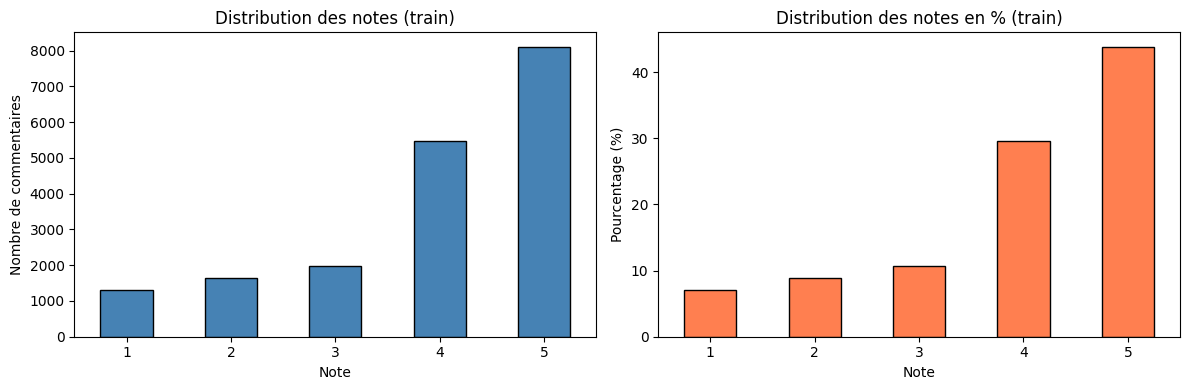

Rating
1    1310
2    1630
3    1982
4    5465
5    8104
Name: count, dtype: int64


In [12]:
# --- Distribution des notes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribution des notes (train)')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre de commentaires')
axes[0].tick_params(axis='x', rotation=0)

(train_df['Rating'].value_counts(normalize=True).sort_index() * 100).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Distribution des notes en % (train)')
axes[1].set_xlabel('Note')
axes[1].set_ylabel('Pourcentage (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(train_df['Rating'].value_counts().sort_index())

=== Longueur des commentaires (en mots) ===
count    18491.0
mean       102.3
std         97.8
min          7.0
25%         48.0
50%         76.0
75%        121.0
max       1931.0
Name: nb_mots, dtype: float64


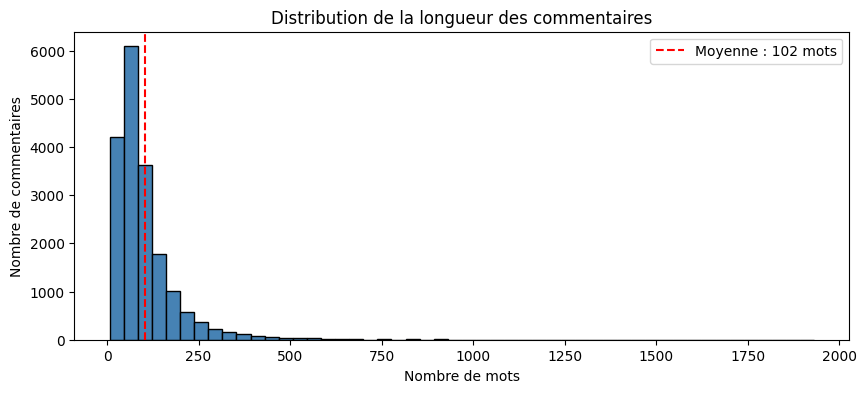

In [13]:
# --- Longueur des commentaires ---
train_df['nb_mots'] = train_df['Review'].astype(str).apply(lambda x: len(x.split()))

print('=== Longueur des commentaires (en mots) ===')
print(train_df['nb_mots'].describe().round(1))

plt.figure(figsize=(10, 4))
plt.hist(train_df['nb_mots'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution de la longueur des commentaires')
plt.xlabel('Nombre de mots')
plt.ylabel('Nombre de commentaires')
plt.axvline(train_df['nb_mots'].mean(), color='red', linestyle='--',
            label=f"Moyenne : {train_df['nb_mots'].mean():.0f} mots")
plt.legend()
plt.show()

## 4. Nettoyage du texte

Pour TF-IDF, on nettoie le texte **agressivement** pour réduire le bruit :
- Mise en minuscules
- Suppression de la ponctuation et des chiffres
- Suppression des stopwords (mots très fréquents sans sens : "the", "a", "is"...)

> Note : ces étapes ne sont **PAS** faites pour BERT (qui gère le texte brut lui-même).

In [ ]:

# Liste des stopwords anglais chargée une seule fois (accès rapide via un set)
# set() → recherche en O(1) au lieu de O(n) pour une liste
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    """
    Nettoie un commentaire pour la vectorisation TF-IDF.

    Pourquoi ce nettoyage ?
    TF-IDF compte les mots — chaque mot différent = une dimension.
    Sans nettoyage, "Hotel", "hotel", "HOTEL" = 3 dimensions distinctes
    pour la même information. Le nettoyage réduit le bruit et la dimensionnalité.

    Ce nettoyage N'est PAS appliqué pour BERT/RoBERTa : ces modèles ont
    été pré-entraînés sur du texte brut et gèrent eux-mêmes la normalisation.
    """
    # 1. Convertir en chaîne — protection si la valeur est NaN (float) dans le CSV
    text = str(text)

    # 2. Mettre en minuscules → "Hotel" et "hotel" deviennent le même token
    text = text.lower()

    # 3. Supprimer les chiffres → "room 204" devient "room"
    #    Les chiffres varient (numéros de chambre, années) → peu informatifs
    text = re.sub(r'\d+', '', text)

    # 4. Supprimer la ponctuation → "good." et "good" deviennent identiques
    #    str.maketrans('', '', chars) crée une table de traduction qui supprime ces chars
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Normaliser les espaces multiples → "  " devient " "
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Supprimer les stopwords
    #    "not good" → après suppression de "not" → "good" (perd le sens négatif !)
    #    C'est une limite connue du nettoyage agressif pour TF-IDF.
    #    RoBERTa conserve "not" car il comprend le contexte.
    tokens = [w for w in text.split() if w not in STOPWORDS]

    return ' '.join(tokens)

# Appliquer sur les 3 jeux de données
# IMPORTANT : même transformation sur train, valid et test pour cohérence
train_df['Review_clean'] = train_df['Review'].apply(clean_text)
valid_df['Review_clean'] = valid_df['Review'].apply(clean_text)
test_df['Review_clean']  = test_df['Review'].apply(clean_text)

# Vérification : avant / après
print('=== Avant nettoyage ===')
print(train_df['Review'].iloc[0][:300])
print('\n=== Après nettoyage ===')
print(train_df['Review_clean'].iloc[0][:300])


## 5. Vectorisation TF-IDF

On transforme chaque commentaire nettoyé en vecteur numérique.

Paramètres clés :
- `max_features=20000` : garder les 20 000 termes les plus informatifs
- `ngram_range=(1, 2)` : capturer aussi les bigrammes (ex: "not good", "very clean")
- `sublinear_tf=True` : applique log(1+tf) pour atténuer l'effet des mots très répétés
- `min_df=3` : ignorer les mots présents dans moins de 3 documents

**Important :** `fit_transform` uniquement sur train pour éviter la fuite de données vers valid/test.

In [ ]:

# ── Labels ───────────────────────────────────────────────────────────────────
# On garde les notes de 1 à 5 telles quelles (sklearn accepte n'importe quel entier).
# Pas besoin de décalage 0-4 ici — c'est uniquement requis pour PyTorch.
y_train = train_df['Rating'].values
y_valid = valid_df['Rating'].values
y_test  = test_df['Rating'].values

print(f'Classes : {sorted(set(y_train))}')

# ── Vectorisation TF-IDF ─────────────────────────────────────────────────────
# Paramètres expliqués :
#
# max_features=20000 : on ne garde que les 20 000 termes les plus fréquents
#   → réduit la dimensionnalité, supprime les mots ultra-rares (noms propres, fautes)
#
# ngram_range=(1, 2) : unigrammes ET bigrammes
#   → unigramme : "good", "clean", "terrible"
#   → bigramme : "not good", "very clean", "highly recommend"
#   Les bigrammes capturent les négations et les expressions figées que
#   les unigrammes seuls ne peuvent pas représenter.
#
# sublinear_tf=True : applique log(1 + tf) au lieu de tf brut
#   → atténue l'effet des mots très répétés dans un même document
#   → "clean" mentionné 10 fois ne vaut pas 10x "clean" mentionné 1 fois
#
# min_df=3 : ignorer les mots présents dans moins de 3 documents
#   → supprime les hapax (mots uniques, fautes de frappe) qui ne généralisent pas
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)

# RÈGLE FONDAMENTALE : fit_transform UNIQUEMENT sur train.
# fit()      : apprend le vocabulaire et les IDF sur les données d'entraînement
# transform(): applique le vocabulaire appris pour vectoriser
#
# Si on fittait sur valid ou test, le modèle "verrait" des mots du futur
# → data leakage → évaluation optimiste et non représentative du monde réel.
X_train = vectorizer.fit_transform(train_df['Review_clean'])  # fit + transform
X_valid = vectorizer.transform(valid_df['Review_clean'])      # transform seulement
X_test  = vectorizer.transform(test_df['Review_clean'])       # transform seulement

print(f'\nDimension X_train : {X_train.shape}  ← (nb_exemples, nb_features)')
print(f'Dimension X_valid : {X_valid.shape}')
print(f'Dimension X_test  : {X_test.shape}')
# Le résultat est une matrice CREUSE (sparse matrix) :
# 18491 × 20000 = 369 820 000 valeurs théoriques
# mais la grande majorité est 0 (la plupart des mots n'apparaissent pas dans chaque doc)
# scipy stocke uniquement les valeurs non nulles → économie mémoire massive.


## 6. Modèle 1 — Logistic Regression

Simple, rapide et interprétable. Bon point de départ.
- `C=1.0` : régularisation (plus C est grand, moins le modèle est régularisé)
- `max_iter=1000` : augmenté pour assurer la convergence

In [ ]:

# ── Entraînement ─────────────────────────────────────────────────────────────
# C=1.0 : régularisation L2 standard
#   → pénalise les poids trop grands pour éviter l'overfitting
#   → plus C est grand, moins le modèle est régularisé (risque d'overfitting)
#   → plus C est petit, plus le modèle est contraint (risque d'underfitting)
# max_iter=1000 : nb max d'itérations pour la convergence (augmenté vs défaut 100)
# random_state=42 : graine aléatoire pour reproductibilité
print('Entraînement Logistic Regression...')
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
# fit() apprend les poids optimaux pour chaque mot du vocabulaire et chaque classe.
# Pour 5 classes, LogisticRegression entraîne 5 classificateurs "one-vs-rest" en interne.
print('Terminé.')

# ── Prédictions sur valid ─────────────────────────────────────────────────────
# On évalue sur valid (jamais sur test avant la fin du projet).
# predict() retourne la classe avec la probabilité la plus élevée.
y_pred_lr = lr_model.predict(X_valid)

# ── Métriques ─────────────────────────────────────────────────────────────────
acc_lr = accuracy_score(y_valid, y_pred_lr)
# accuracy = nb bonnes prédictions / nb total
# Attention : trompeur sur données déséquilibrées (44% de 5★)

f1_lr  = f1_score(y_valid, y_pred_lr, average='macro')
# F1 macro = moyenne des F1 de chaque classe (poids égal pour 1★ et 5★)
# Plus juste que l'accuracy pour évaluer la performance sur les classes rares

print(f'\n=== Logistic Regression — Résultats sur valid ===')
print(f'Accuracy         : {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print(f'F1-score (macro) : {f1_lr:.4f}')
print(f'\n--- Rapport par classe ---')
print(classification_report(y_valid, y_pred_lr, target_names=['1 etoile','2 etoiles','3 etoiles','4 etoiles','5 etoiles']))
# precision : sur tous les avis prédits 3★, combien étaient vraiment 3★ ?
# recall    : sur tous les vrais 3★, combien a-t-on correctement identifiés ?
# f1-score  : moyenne harmonique précision/rappel
# support   : nb d'exemples réels de chaque classe dans valid


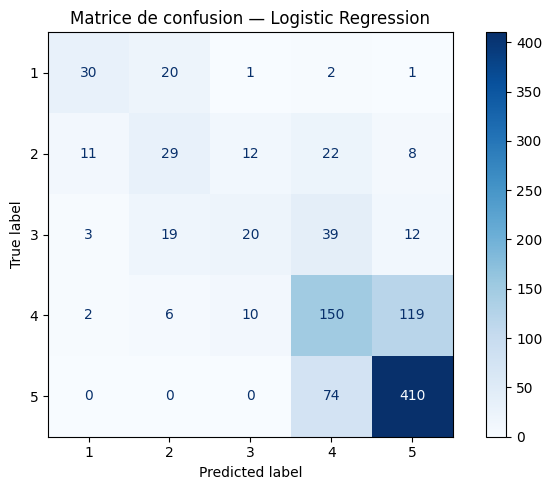

In [17]:
# --- Matrice de confusion — Logistic Regression ---
# Ligne = note réelle, Colonne = note prédite
# Diagonale = bonnes prédictions
cm_lr = confusion_matrix(y_valid, y_pred_lr)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['1','2','3','4','5'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Matrice de confusion — Logistic Regression')
plt.tight_layout()
plt.show()

## 7. Modèle 2 — LinearSVC

SVM linéaire. Souvent plus performant que LogisticRegression sur du texte.
- `C=1.0` : paramètre de marge
- `max_iter=2000` : SVM peut nécessiter plus d'itérations

In [ ]:

# ── Entraînement ─────────────────────────────────────────────────────────────
# LinearSVC est souvent plus rapide que LogisticRegression sur du texte
# car il optimise directement la marge (pas de probabilités calculées).
# C=1.0 : même régularisation que LogisticRegression pour comparaison équitable
# max_iter=2000 : SVM peut nécessiter plus d'itérations que LogReg pour converger
print('Entraînement LinearSVC...')
svc_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svc_model.fit(X_train, y_train)
print('Terminé.')

# ── Prédictions ──────────────────────────────────────────────────────────────
y_pred_svc = svc_model.predict(X_valid)

# ── Métriques ────────────────────────────────────────────────────────────────
acc_svc = accuracy_score(y_valid, y_pred_svc)
f1_svc  = f1_score(y_valid, y_pred_svc, average='macro')

print(f'\n=== LinearSVC — Résultats sur valid ===')
print(f'Accuracy         : {acc_svc:.4f} ({acc_svc*100:.2f}%)')
print(f'F1-score (macro) : {f1_svc:.4f}')
print(f'\n--- Rapport par classe ---')
print(classification_report(y_valid, y_pred_svc, target_names=['1 etoile','2 etoiles','3 etoiles','4 etoiles','5 etoiles']))
# Note : contrairement à LogisticRegression, LinearSVC ne produit pas de probabilités
# → predict() retourne directement la classe, pas un score de confiance


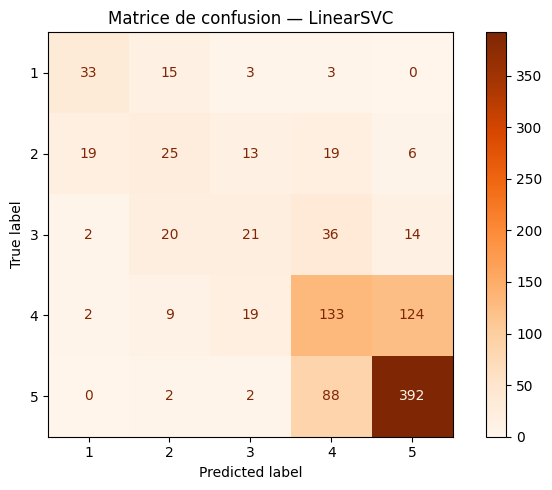

In [19]:
# --- Matrice de confusion — LinearSVC ---
cm_svc = confusion_matrix(y_valid, y_pred_svc)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=['1','2','3','4','5'])
disp.plot(cmap='Oranges', ax=plt.gca())
plt.title('Matrice de confusion — LinearSVC')
plt.tight_layout()
plt.show()

## 8. Comparaison des deux modèles

             Modele  Accuracy  F1-score (macro)
Logistic Regression     0.639            0.5163
          LinearSVC     0.604            0.4887


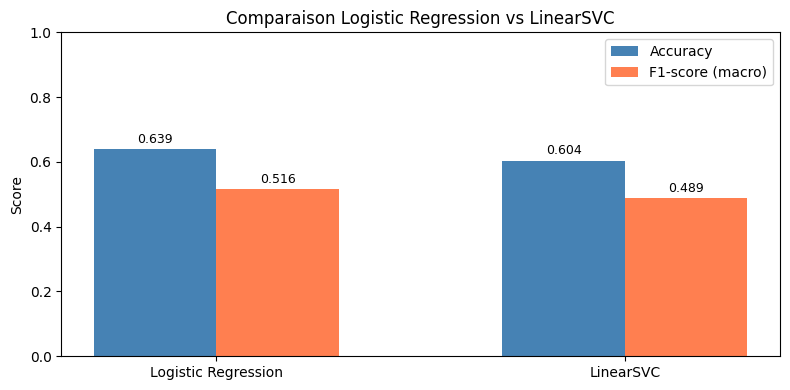

In [20]:
# --- Tableau comparatif ---
results = pd.DataFrame({
    'Modele'           : ['Logistic Regression', 'LinearSVC'],
    'Accuracy'         : [round(acc_lr, 4), round(acc_svc, 4)],
    'F1-score (macro)' : [round(f1_lr,  4), round(f1_svc,  4)]
}).sort_values('F1-score (macro)', ascending=False)
print(results.to_string(index=False))

# --- Graphique comparatif ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
w = 0.3

bars1 = ax.bar(x - w/2, [acc_lr, acc_svc], w, label='Accuracy',         color='steelblue')
bars2 = ax.bar(x + w/2, [f1_lr,  f1_svc],  w, label='F1-score (macro)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'LinearSVC'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparaison Logistic Regression vs LinearSVC')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Analyse des erreurs

On examine les cas où le meilleur modèle s'est trompé pour comprendre ses limites.

In [21]:
# Choisir automatiquement le meilleur modèle selon le F1-score
best_model_name = 'LinearSVC' if f1_svc >= f1_lr else 'Logistic Regression'
y_pred_best     = y_pred_svc  if f1_svc >= f1_lr else y_pred_lr
print(f'Meilleur modèle : {best_model_name}')

# Ajouter les prédictions au dataframe
valid_df = valid_df.copy()
valid_df['pred']    = y_pred_best
valid_df['correct'] = valid_df['Rating'] == valid_df['pred']

errors = valid_df[~valid_df['correct']].copy()
print(f'Erreurs : {len(errors)} / {len(valid_df)}')

print('\n=== 5 exemples mal classés ===')
for _, row in errors.head(5).iterrows():
    print(f'\nNote réelle : {row["Rating"]} | Note prédite : {row["pred"]}')
    print(f'Commentaire : {str(row["Review"])[:200]}...')
    print('-' * 60)

Meilleur modèle : Logistic Regression
Erreurs : 361 / 1000

=== 5 exemples mal classés ===

Note réelle : 3 | Note prédite : 4
Commentaire : interesting wife traveled years hotel ups downs certain qualities bugged most.first ups hotel staff not nicer, bar folks waiters desk, pleased attitude service around.we mainly ate buffets really n't ...
------------------------------------------------------------

Note réelle : 4 | Note prédite : 5
Commentaire : animation team impressed animation team resort, special thank pablo jesus wassiel,  ...
------------------------------------------------------------

Note réelle : 1 | Note prédite : 2
Commentaire : majestic hotel putan cana-awful assuming people rave majestic single young children questionable, husband traveled extensively stayed 4 5 star hotels, hotel not close 4 5 star hotel, room tiny broken ...
------------------------------------------------------------

Note réelle : 4 | Note prédite : 5
Commentaire : beautiful hotel island fiance 

=== Écart entre note réelle et prédite (erreurs uniquement) ===
ecart
1    304
2     44
3     12
4      1
Name: count, dtype: int64


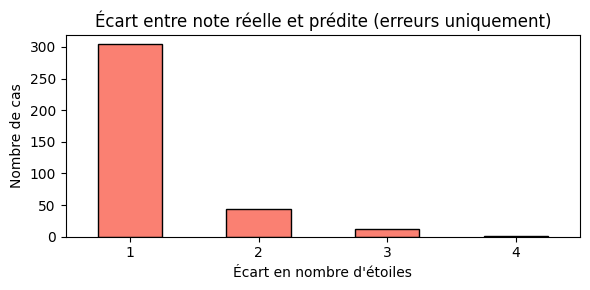

In [22]:
# --- De combien d'étoiles se trompe-t-on en moyenne ? ---
# Écart 1 (ex: prédit 4 au lieu de 5) est moins grave qu'un écart de 3
errors['ecart'] = (errors['Rating'] - errors['pred']).abs()

print('=== Écart entre note réelle et prédite (erreurs uniquement) ===')
print(errors['ecart'].value_counts().sort_index())

plt.figure(figsize=(6, 3))
errors['ecart'].value_counts().sort_index().plot(
    kind='bar', color='salmon', edgecolor='black'
)
plt.title("Écart entre note réelle et prédite (erreurs uniquement)")
plt.xlabel("Écart en nombre d'étoiles")
plt.ylabel('Nombre de cas')
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 10. Prédiction finale sur le jeu de test

On applique le meilleur modèle sur le jeu de test et on sauvegarde les résultats.

In [23]:
best_model  = svc_model if f1_svc >= f1_lr else lr_model
y_pred_test = best_model.predict(X_test)

# Évaluation sur test si les labels sont disponibles
if 'Rating' in test_df.columns and test_df['Rating'].notna().all():
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test  = f1_score(y_test, y_pred_test, average='macro')
    print(f'=== {best_model_name} — Résultats sur TEST ===')
    print(f'Accuracy         : {acc_test:.4f} ({acc_test*100:.2f}%)')
    print(f'F1-score (macro) : {f1_test:.4f}')
    print(classification_report(y_test, y_pred_test,
          target_names=['1 etoile','2 etoiles','3 etoiles','4 etoiles','5 etoiles']))

# Sauvegarder les prédictions
pd.DataFrame({
    'Review'        : test_df['Review'],
    'Rating_reel'   : test_df['Rating'],
    'Rating_predit' : y_pred_test
}).to_csv('predictions_tfidf.csv', index=False)

print('Prédictions sauvegardées dans predictions_tfidf.csv')

=== Logistic Regression — Résultats sur TEST ===
Accuracy         : 0.6130 (61.30%)
F1-score (macro) : 0.4930
              precision    recall  f1-score   support

    1 etoile       0.67      0.58      0.62        57
   2 etoiles       0.43      0.36      0.39        81
   3 etoiles       0.41      0.12      0.18       109
   4 etoiles       0.47      0.51      0.49       287
   5 etoiles       0.73      0.84      0.78       466

    accuracy                           0.61      1000
   macro avg       0.54      0.48      0.49      1000
weighted avg       0.59      0.61      0.59      1000

Prédictions sauvegardées dans predictions_tfidf.csv


## 11. Résumé final

In [24]:
print('=' * 50)
print('RÉSUMÉ FINAL — TF-IDF + Classification')
print('=' * 50)
print(f'Taille vocabulaire TF-IDF : {X_train.shape[1]} features')
print(f'Données entraînement      : {X_train.shape[0]} exemples')
print()
print(f'Logistic Regression — Accuracy: {acc_lr:.4f} | F1: {f1_lr:.4f}')
print(f'LinearSVC           — Accuracy: {acc_svc:.4f} | F1: {f1_svc:.4f}')
print()
print(f'Meilleur modèle : {best_model_name}')
print()
print('Prochaine étape : BERT fine-tuning pour comparer.')
print('=' * 50)

RÉSUMÉ FINAL — TF-IDF + Classification
Taille vocabulaire TF-IDF : 20000 features
Données entraînement      : 18491 exemples

Logistic Regression — Accuracy: 0.6390 | F1: 0.5163
LinearSVC           — Accuracy: 0.6040 | F1: 0.4887

Meilleur modèle : Logistic Regression

Prochaine étape : BERT fine-tuning pour comparer.
